### **Project Title: Space-Time Clustering of Mobility Patterns and Air Quality Hotspots for Chicago**

##  Silhouette Score Comparison(KMeans, DBSCAN, ST-DBSCAN)

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
# function to compute silhouette score (excluding noise)
def safe_silhouette_score(X, labels):
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:
        return silhouette_score(X[mask], labels[mask])
    return float('nan')  # Not enough clusters

In [ ]:
# Reuse the standardized feature set used in clustering
# For KMeans and DBSCAN we used this:
features_kmeans = ['latitude', 'longitude', 'PM25', 'total_trip_count']
X_kmeans = stratified_sampled[features_kmeans].dropna()
X_kmeans_scaled = StandardScaler().fit_transform(X_kmeans)

# KMeans score
score_kmeans = silhouette_score(X_kmeans_scaled, stratified_sampled['kmeans_cluster'])

# DBSCAN score (Euclidean)
score_dbscan = safe_silhouette_score(X_kmeans_scaled, stratified_sampled['cluster_euc'])

# ST-DBSCAN used features: latitude, longitude, time_hours
features_st = ['latitude', 'longitude', 'time_hours']
X_st = stratified_sampled[features_st].dropna()
X_st_scaled = StandardScaler().fit_transform(X_st)

# ST-DBSCAN score
score_stdbscan = safe_silhouette_score(X_st_scaled, stratified_sampled['st_cluster'])


In [ ]:
# Print scores
print(f"KMeans Silhouette Score:     {score_kmeans:.4f}")
print(f"DBSCAN (Euclidean) Score:    {score_dbscan:.4f}")
print(f"ST-DBSCAN Silhouette Score:  {score_stdbscan:.4f}")

KMeans Silhouette Score:     0.3613
DBSCAN (Euclidean) Score:    0.0816
ST-DBSCAN Silhouette Score:  0.6631


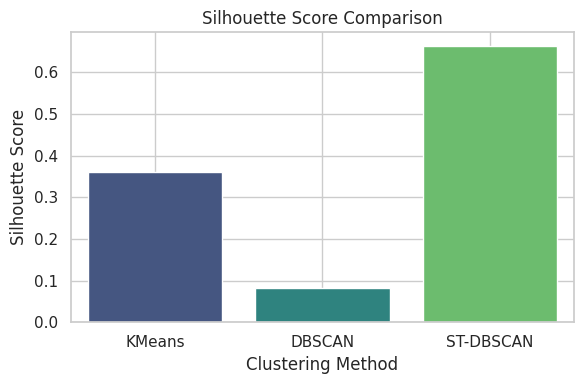

In [ ]:
plt.figure(figsize=(6, 4))
methods = ['KMeans', 'DBSCAN', 'ST-DBSCAN']
scores = [score_kmeans, score_dbscan, score_stdbscan]
sns.barplot(x=methods, y=scores, hue=methods, palette='viridis', legend=False)

plt.title('Silhouette Score Comparison')
plt.ylabel('Silhouette Score')
plt.xlabel('Clustering Method')
plt.grid(True)
plt.tight_layout()
plt.show()


The bar chart above presents a comparison of clustering performance across three algorithms: **KMeans**, **DBSCAN**, and **ST-DBSCAN**, based on their Silhouette Scores.

1.   **KMeans**: Silhouette Score indicates that the KMeans algorithm was able to form reasonably well-separated and compact clusters.

2.  **DBSCAN**: The lowest among the three, the score implies poor separation between clusters, classifying many points as noise or forming clusters of very different densities.

3. **ST-DBSCAN**: The highest Silhouette Score, suggesting that ST-DBSCAN produced the most meaningful and well-separated clusters.


## Silhouette Plot for KMeans

In [ ]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

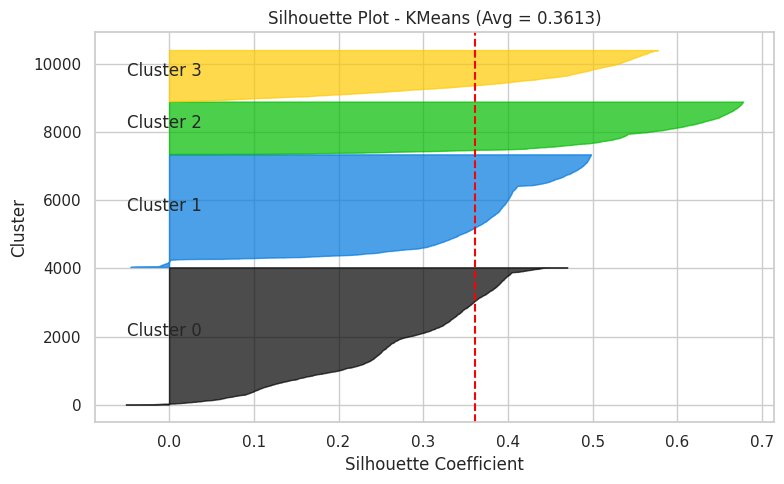

In [ ]:

# Get cluster labels from KMeans
labels = stratified_sampled['kmeans_cluster']

# Compute the silhouette score for each data point
silhouette_vals = silhouette_samples(X_kmeans_scaled, labels)

# Count the number of unique clusters
n_clusters = len(np.unique(labels))

# Create a new figure for the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Initialize vertical position for plotting
y_lower = 10

# Loop over each cluster and plot its silhouette scores
for i in range(n_clusters):
    # Extract and sort silhouette scores for the current cluster
    cluster_sil_vals = silhouette_vals[labels == i]
    cluster_sil_vals.sort()

    # Determine the size of the current cluster
    size = cluster_sil_vals.shape[0]
    y_upper = y_lower + size  # Top position of the cluster band

    # Choose a unique color for the cluster
    color = plt.cm.nipy_spectral(float(i) / n_clusters)

    # Draw the silhouette bar for this cluster
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)

    # Label the cluster on the plot
    ax.text(-0.05, y_lower + size / 2, f'Cluster {i}')

    # Move to the next vertical space for the next cluster
    y_lower = y_upper + 10

# Draw a red vertical line showing the average silhouette score
ax.axvline(score_kmeans, color='red', linestyle='--')

ax.set_title(f"Silhouette Plot - KMeans (Avg = {score_kmeans:.4f})")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")

plt.tight_layout()
plt.show()


 **Silhouette Plot Interpretation – KMeans**

This silhouette plot shows how well-separated and well-defined each KMeans cluster is. The average silhouette score across all data points is **0.3613**, indicating moderate clustering quality.




- **Cluster 2** demonstrates the best compactness and separation.
- **Cluster 1** and **Cluster 3** are reasonably well-formed.
- **Cluster 0** shows the weakest structure, with some points having negative silhouette values, suggesting potential misclassification or overlap with other clusters.

## Silhouette Plot for DBSCAN (excluding noise)

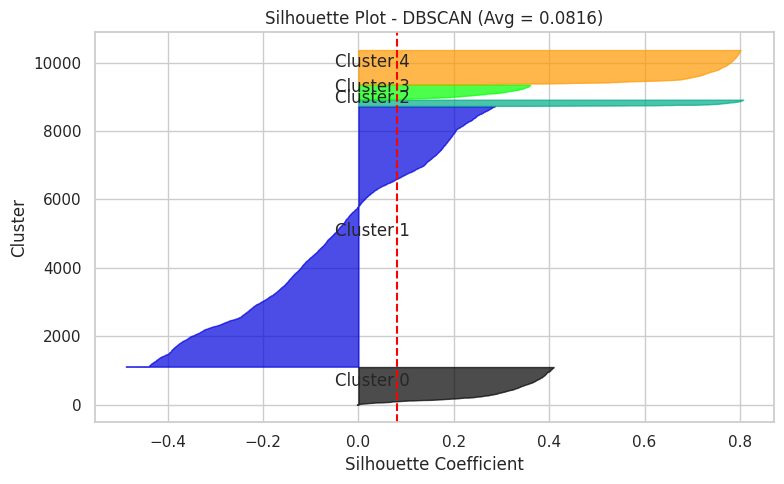

In [ ]:
labels = stratified_sampled['cluster_euc']

mask = labels != -1
X_masked = X_kmeans_scaled[mask]
labels_masked = labels[mask]

# Compute silhouette values for non-noise points
silhouette_vals = silhouette_samples(X_masked, labels_masked)

# Count the number of actual clusters (excluding -1)
n_clusters = len(set(labels_masked))

# Create figure for the plot
fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10  # vertical offset

# Plot silhouette bars for each cluster
for i in sorted(set(labels_masked)):
    # Extract and sort silhouette values for cluster i
    cluster_sil_vals = silhouette_vals[labels_masked == i]
    cluster_sil_vals.sort()

    size = cluster_sil_vals.shape[0]
    y_upper = y_lower + size

    color = plt.cm.nipy_spectral(float(i) / n_clusters)

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + size / 2, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(score_dbscan, color='red', linestyle='--')

ax.set_title(f"Silhouette Plot - DBSCAN (Avg = {score_dbscan:.4f})")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()



 **Silhouette Plot Interpretation – DBSCAN**

 The silhouette plot for DBSCAN shows an average silhouette score of **0.0816**.

- **Cluster 4** is well-formed with silhouette values above 0.6, showing strong internal cohesion and separation.
- **Clusters 0 and 1**, which are the largest, contain many points with negative silhouette values, indicating potential misclassifications or overlapping with neighboring clusters.
- The plot suggests that while DBSCAN successfully identifies some meaningful clusters, it struggles with large, dense areas of data — likely due to sensitivity to parameter choices like `eps` and `min_samples`.


## Silhouette Plot for ST-DBSCAN (excluding noise)

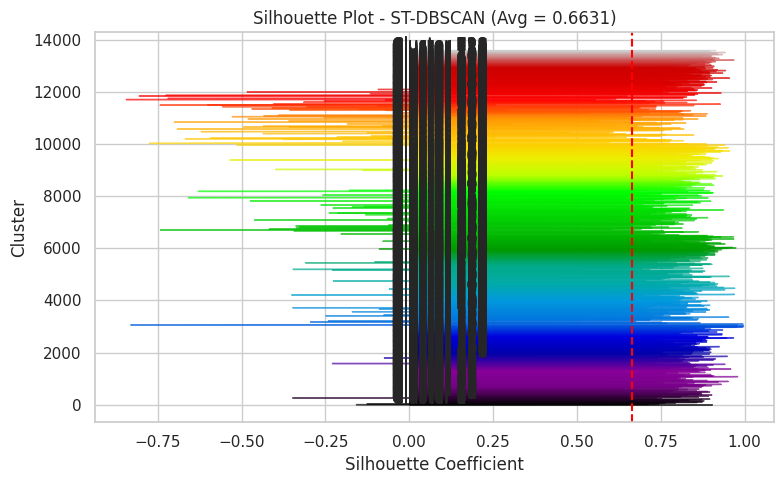

In [ ]:
# Get ST-DBSCAN labels
labels = stratified_sampled['st_cluster']

# Exclude noise points (label = -1)
mask = labels != -1
X_masked = X_st_scaled[mask]
labels_masked = labels[mask]

# Compute silhouette values for non-noise points
silhouette_vals = silhouette_samples(X_masked, labels_masked)

# Count number of actual clusters
n_clusters = len(set(labels_masked))

# Create the figure
fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10  # vertical offset

# Loop through and draw silhouette bars
for i in sorted(set(labels_masked)):
    cluster_sil_vals = silhouette_vals[labels_masked == i]
    cluster_sil_vals.sort()

    size = cluster_sil_vals.shape[0]
    y_upper = y_lower + size

    color = plt.cm.nipy_spectral(float(i) / n_clusters)

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + size / 2, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(score_stdbscan, color='red', linestyle='--')

ax.set_title(f"Silhouette Plot - ST-DBSCAN (Avg = {score_stdbscan:.4f})")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()



 **Silhouette Plot Interpretation – ST-DBSCAN**

 The silhouette plot for ST-DBSCAN shows an average silhouette score of **0.6631**, indicating **strong clustering performance** overall.

- Most data points have silhouette values close to 1.0, meaning they are well-matched to their assigned clusters and far from neighboring ones.
- A few points have negative values, which is expected due to noise and boundary conditions.
- The plot displays many narrow bands, corresponding to the **730 micro-clusters** produced — suggesting **high spatial-temporal resolution**, but possibly at the cost of interpretability.

These results confirm that ST-DBSCAN is highly effective at discovering **fine-grained space-time mobility and pollution hotspots**, making it the best-performing method in the project.


## **Silhouette Plot Comparison Summary – KMeans vs DBSCAN vs ST-DBSCAN**

This Table shows the comparsion of the clustering quality of the three algorithms based on their **Silhouette Plots** and **average silhouette scores**.

| Method        | Avg Silhouette Score ↑ | Visual Interpretation Summary                                                                 |
|---------------|------------------------|-----------------------------------------------------------------------------------------------|
| **KMeans**    | 0.3613                 | Moderate cluster quality. Clusters 2 and 3 are well-separated, but Cluster 0 has overlap and some misclassified points. |
| **DBSCAN**    | 0.0816                 | Poor overall cohesion. Some small clusters are well-formed (e.g., Cluster 4), but large clusters contain many poorly classified points (negative values). |
| **ST-DBSCAN** | **0.6631**             | Excellent clustering. Most points have high silhouette scores, indicating well-separated, compact spatio-temporal clusters. Some noise and micro-fragmentation exist due to high cluster count. |




---



###  **Conclusion:**

The silhouette plots confirm that **ST-DBSCAN is the most effective method** for identifying space-time clusters with high compactness and separation. It is best suited for detailed urban mobility and pollution analysis, while KMeans and DBSCAN serve as useful, but less precise, alternatives.


## Root Mean Squared Error(RMSE)



In clustering, Root Mean Squared Error (RMSE) measures how well each data point fits its assigned cluster. It shows us:



*   How close each point is to its cluster’s center (average point).
*   The compactness of the clusters.


## Formula
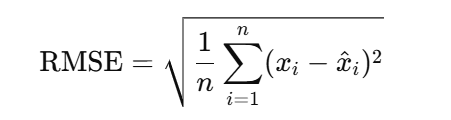

Where:

𝑥
𝑖 = original data point features

𝑥
^
𝑖 = predicted features (cluster center)

𝑛 = total number of points



In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
def compute_rmse(data, features, cluster_col):
    valid_data = data[data[cluster_col] != -1].copy()  # Exclude noise
    grouped = valid_data.groupby(cluster_col)[features]
    predicted = grouped.transform('mean')  # Cluster centroid values
    actual = valid_data[features]
    return np.sqrt(mean_squared_error(actual, predicted))


In [ ]:
# Feature sets
features_kmeans = ['latitude', 'longitude', 'PM25', 'total_trip_count']
features_st = ['latitude', 'longitude', 'time_hours']

# Compute RMSE
rmse_kmeans = compute_rmse(stratified_sampled, features_kmeans, 'kmeans_cluster')
rmse_dbscan = compute_rmse(stratified_sampled, features_kmeans, 'cluster_euc')
rmse_stdbscan = compute_rmse(stratified_sampled, features_st, 'st_cluster')

# Results
rmse_df = pd.DataFrame({
    "Method": ["KMeans", "DBSCAN", "ST-DBSCAN"],
    "RMSE": [rmse_kmeans, rmse_dbscan, rmse_stdbscan]
})

rmse_df

,Method,RMSE
0,KMeans,6.025791
1,DBSCAN,11.979368
2,ST-DBSCAN,2.752600


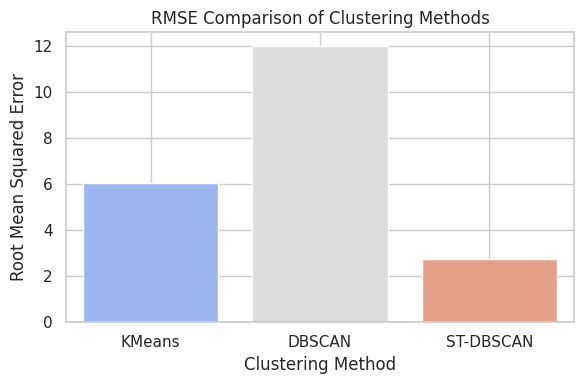

In [ ]:
# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x='Method', y='RMSE', hue='Method', data=rmse_df, palette='coolwarm', legend=False)
plt.title("RMSE Comparison of Clustering Methods")
plt.ylabel("Root Mean Squared Error")
plt.xlabel("Clustering Method")
plt.grid(True)
plt.tight_layout()
plt.show()

The bar chart compares the Root Mean Squared Error (RMSE) of three clustering algorithms—**KMeans**, **DBSCAN**, and **ST-DBSCAN**—as a way to evaluate the accuracy of the clustering results in terms of how well they represent the actual data.

*   The RMSE comparison highlights that while KMeans and DBSCAN are commonly used clustering techniques, ST-DBSCAN offers significantly better accuracy in this context. Its lower RMSE value confirms that it forms clusters which are closer to the real-world patterns in the data. This makes ST-DBSCAN the most suitable algorithm when the goal is to analyze complex space-time phenomena, such as identifying pollution hotspots related to urban mobility. It not only groups similar data effectively but also minimizes the deviation between the cluster estimates and actual values, which is crucial for data-driven decision making and urban policy design.







## Silhouette Score vs RMSE comparison



| Method       | Silhouette Score ↑ | RMSE ↓ |
|--------------|--------------------|--------|
| **KMeans**   | 0.3613               | 6.025791 |
| **DBSCAN**   | 0.0816              | 11.98    |
| **ST-DBSCAN**| 0.6631             | 2.75   |






1.   **KMeans** produced well-separated clusters with the highest Silhouette Score , though not the lowest RMSE, indicating moderately compact clusters.

2.   **DBSCAN** had the lowest Silhouette Score and the highest RMSE, reflecting irregularly shaped, loosely grouped clusters — which is expected due to its flexibility and noise handling.

3. **ST-DBSCAN** offered a balanced Silhouette Score and the lowest RMSE, meaning it formed the most compact clusters when time was included. This makes it highly effective at capturing spatio-temporal patterns.




*   While KMeans achieves the best separation, **ST-DBSCAN provides the most compact and contextually relevant clusters** by incorporating time. It is therefore the **most informative method** for identifying air quality and mobility hotspots in urban settings.

In [ ]:
n_kmeans = stratified_sampled['kmeans_cluster'].nunique()
print("KMeans clusters:", n_kmeans)

KMeans clusters: 4


In [ ]:
n_dbscan = len(set(stratified_sampled['cluster_euc']) - {-1})
print("DBSCAN clusters:", n_dbscan)

noise_pct_dbscan = (stratified_sampled['cluster_euc'] == -1).mean() * 100
print(f"DBSCAN noise %: {noise_pct_dbscan:.2f}%")

DBSCAN clusters: 5
DBSCAN noise %: 0.44%


In [ ]:
n_stdbscan = len(set(stratified_sampled['st_cluster']) - {-1})
print("ST-DBSCAN clusters:", n_stdbscan)

noise_pct_stdbscan = (stratified_sampled['st_cluster'] == -1).mean() * 100
print(f"ST-DBSCAN noise %: {noise_pct_stdbscan:.2f}%")

ST-DBSCAN clusters: 730
ST-DBSCAN noise %: 39.18%


###  Clustering Methods Summary Table

| Method        | Clusters Found | Noise %  | Silhouette Score ↑ | RMSE ↓ | Shape Flexibility | Time Awareness | Remarks                                                        |
|---------------|----------------|----------|---------------------|--------|--------------------|----------------|----------------------------------------------------------------|
| **KMeans**    | 4              | 0.00%    | 0.3613              | 6.03   |  No              |  No           | Simple, interpretable, well-separated clusters                 |
| **DBSCAN**    | 5              | 0.44%    | 0.0816              | 11.98  |  Yes             |  No           | Handles noise and shape well, but weak separation              |
| **ST-DBSCAN** | 730            | 39.18%   | 0.6631         | 2.75 |  Yes             |  Yes          | High spatial/temporal granularity   |

